# **Estatus de la Salud Mental en adultos del municipio más acaudalado de América Látina.**

Reporte técnico del análisis de la salud mental en adultos dentro de la población en edad de trabajar del municipio de San Pedro Garza García.

**Hecho por: Estefania Nájera de la Rosa - estefania.najera@udem.edu a 19 de marzo del 2026.**

In [419]:
# Importar las librerías.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.metrics import accuracy_score, f1_score

# 1.1 Introducción.

Para el presente estudio, se tomará como base el dataset utilizado en el proyecto del primer parcial de la materia de Inteligencia Artifical, el cuál para este caso se trata de registros de adultos en la edad económicamente activa (18-65 años) que residen en el municipio de San Pedro Garza García, ubicado en el estado de Nuevo León y que corresponde al área metropolitana de Monterrey.

A diferencia del proyecto del primer parcial donde se realizó tanto una Regresión Lineal Múltiple como un Random Forest Regressor, en esta ocasión se realizará un Random Forest Classifier, un Boosting, un Support Vector Machine (SVM) y una Red Neuronal construida desde cero.

# 1.2 Objetivo.

El objetivo de este estudio es aplicar los diversos modelos para formar métodos de ensamble, máquinas de soporte vectorial y redes neuronales, donde para los mismos se busca predecir la probabilidad de 0 a 1, esto con el propósito de obtener solo 2 respuestas probables, llamado clasificación.

En este caso, se busca conocer si una persona recae en alguno de los siguientes grupos:
* Trastornos mentales y del comportamiento.

* Factores que influyen en el estado de salud y contacto con los servicios de salud.

Esto para saber si el/la individuo(a) padece una enfermedad como tal que necesita ser tratada profesionalmente (primer grupo) o si solo requiere de una terapia sin necesidad de caer en un tratamiento que necesite ser guiado bajo un especialista.

# 2.1 Descripción del conjunto de datos.

Como se mencionó anteriormente, el dataset utilizdo es el mismo que el del proyecto del primer parcial, estos provienen del portal de datos abiertos del Gobierno del Estado de Nuevo León dentro del periodo de octubre del 2024 a agosto del 2025.

El dataset seleccionado contiene datos de varios municipios del estado de Nuevo León, por mencionar algunos que pertenecen al área metropólitana como:
* Monterrey.

* San Nicolás de los Garza.

* Santa Catarina.

* General Escobedo.

entre otros.

Sin dejar de lado que también hay datos de municipios aledaños a la metrópoli como lo son:
* Montemorelos.

* Linares.

* Cadereyta Jiménez.

entre otros.

Por cada municipio, es que se tiene registrado por individuo lo siguiente:
* Fecha de la consulta.

* Número de identificación de la consulta.

* Básicos de la persona como edad, sexo, peso y altura.

* Municipio.

* Institución médica dentro del municipio.

* Número de identificación y descripción de su grupo de enfermedad.

In [420]:
# Cargar los datos.
url = 'https://raw.githubusercontent.com/estefaniadelarosa/IA-I/refs/heads/main/P1.%20Regresi%C3%B3n/P1.%20Regresi%C3%B3n/2024_2025_salud_mental.csv'
df = pd.read_csv(url)
print(df.shape)
df.head()

(48224, 14)


,fecha,id_consulta,edad,edad_meses,edad_dias,sexo,peso,altura,municipio_unidad_medica,institucion_unidad_medica,clave_grupo_ enfermedad,descripcion_grupo_enfermedad,clave_enfermedad,descripcion_enfermedad
0,02/10/2024,SM_2024_38869,21,0,0,Masculino,82,174,LINARES,HOSPITAL GENERAL DE LINARES,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION
1,08/10/2024,SM_2024_38870,21,0,0,Masculino,82,174,LINARES,HOSPITAL GENERAL DE LINARES,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION
2,08/10/2024,SM_2024_38871,5,0,0,Masculino,21,111,LINARES,HOSPITAL GENERAL DE LINARES,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F919,TRASTORNO DE LA CONDUCTA NO ESPECIFICADO
3,09/10/2024,SM_2024_38872,69,0,0,Masculino,sin valor,sin valor,LINARES,HOSPITAL GENERAL DE LINARES,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F321,EPISODIO DEPRESIVO MODERADO
4,09/10/2024,SM_2024_38873,78,0,0,Masculino,sin valor,sin valor,LINARES,HOSPITAL GENERAL DE LINARES,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F321,EPISODIO DEPRESIVO MODERADO


# 2.2 Preparación y limpieza del conjunto de datos.

Justo como en el proyecto, se filtrarán los datos a que estos sean solamente del municipio de San Pedro Garza García y que dichos contengan a individuos dentro del rango de edad de 18 a 65 años.

In [421]:
df1 = df[df['municipio_unidad_medica'] == 'SAN PEDRO GARZA GARCIA']
print(df1.shape)
df1.head()

(1060, 14)


,fecha,id_consulta,edad,edad_meses,edad_dias,sexo,peso,altura,municipio_unidad_medica,institucion_unidad_medica,clave_grupo_ enfermedad,descripcion_grupo_enfermedad,clave_enfermedad,descripcion_enfermedad
2625,02/10/2024,SM_2024_41494,33,0,0,Masculino,60,160,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F122,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO DEBID...
2626,02/10/2024,SM_2024_41495,53,0,0,Femenino,60,160,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION
2627,02/10/2024,SM_2024_41496,60,0,0,Femenino,60,160,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F630,JUEGO PATOLOGICO
2628,04/10/2024,SM_2024_41497,46,0,0,Femenino,70,165,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION
2629,04/10/2024,SM_2024_41498,47,0,0,Femenino,60,160,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION


In [422]:
# Aplicar el filtro de personas dentro del rango de edad de 18 a 65 años.
df2 = df1[(df1['edad'] >= 18) & (df1['edad'] <= 65)]
print(df2.shape)
df2.head()

(720, 14)


,fecha,id_consulta,edad,edad_meses,edad_dias,sexo,peso,altura,municipio_unidad_medica,institucion_unidad_medica,clave_grupo_ enfermedad,descripcion_grupo_enfermedad,clave_enfermedad,descripcion_enfermedad
2625,02/10/2024,SM_2024_41494,33,0,0,Masculino,60,160,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F122,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO DEBID...
2626,02/10/2024,SM_2024_41495,53,0,0,Femenino,60,160,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION
2627,02/10/2024,SM_2024_41496,60,0,0,Femenino,60,160,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F630,JUEGO PATOLOGICO
2628,04/10/2024,SM_2024_41497,46,0,0,Femenino,70,165,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION
2629,04/10/2024,SM_2024_41498,47,0,0,Femenino,60,160,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION


In [423]:
df2.dtypes

fecha                           object
id_consulta                     object
edad                             int64
edad_meses                       int64
edad_dias                        int64
sexo                            object
peso                            object
altura                          object
municipio_unidad_medica         object
institucion_unidad_medica       object
clave_grupo_ enfermedad         object
descripcion_grupo_enfermedad    object
clave_enfermedad                object
descripcion_enfermedad          object
dtype: object

Los datos y su tipo que disponemos son los siguientes:
* id_consulta → object

* edad → int64

* sexo → object

* peso → object

* altura → object

* municipio_unidad_medica → object

* institucion_unidad_medica → object

* clave_grupo_ enfermedad → object

* descripcion_grupo_enfermedad → object

* clave_enfermedad → object

* descripcion_enfermedad → object

Por ende, las que se transformarán mediante LabelEncoder son las siguientes:
* sexo

* institucion_unidad_medica

* descripcion_grupo_enfermedad_num

* clave_enfermedad_num

Esto para poder manipular las mismas más adelante.

In [424]:
# Convertimos las variables categóricas a categóricas numéricas.
from sklearn.preprocessing import LabelEncoder 

# Aplicamos la transformación.
df2['sexo_num'] = LabelEncoder().fit_transform(df2['sexo'])
df2['institucion_unidad_medica_num'] = LabelEncoder().fit_transform(df2['institucion_unidad_medica'])
df2['descripcion_grupo_enfermedad_num'] = LabelEncoder().fit_transform(df2['descripcion_grupo_enfermedad'])
df2['clave_enfermedad_num'] = LabelEncoder().fit_transform(df2['clave_enfermedad'])
df2['descripcion_enfermedad_num'] = LabelEncoder().fit_transform(df2['descripcion_enfermedad'])

df2.sample(5)

/var/folders/rw/krrrqrzn68j3jq_d4yl8mzk80000gn/T/ipykernel_27490/763801538.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['sexo_num'] = LabelEncoder().fit_transform(df2['sexo'])
/var/folders/rw/krrrqrzn68j3jq_d4yl8mzk80000gn/T/ipykernel_27490/763801538.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['institucion_unidad_medica_num'] = LabelEncoder().fit_transform(df2['institucion_unidad_medica'])
/var/folders/rw/krrrqrzn68j3jq_d4yl8mzk80000gn/T/ipykernel_27490/763801538.py:7: SettingWithCopy

,fecha,id_consulta,edad,edad_meses,edad_dias,sexo,peso,altura,municipio_unidad_medica,institucion_unidad_medica,clave_grupo_ enfermedad,descripcion_grupo_enfermedad,clave_enfermedad,descripcion_enfermedad,sexo_num,institucion_unidad_medica_num,descripcion_grupo_enfermedad_num,clave_enfermedad_num,descripcion_enfermedad_num
18742,05/02/2025,SM_2025_5878,56,0,0,Femenino,74.5,162,SAN PEDRO GARZA GARCIA,CENTRO DE SALUD CON SERVICIOS AMPLIADOS SAN PE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F431,TRASTORNO DE ESTRES POSTRAUMATICO,0,1,1,36,30
32289,20/05/2025,SM_2025_19425,50,0,0,Femenino,51.5,147,SAN PEDRO GARZA GARCIA,CENTRO DE SALUD CON SERVICIOS AMPLIADOS SAN PE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F341,DISTIMIA,0,1,1,29,2
46578,12/08/2025,SM_2025_33714,60,0,0,Femenino,116,158,SAN PEDRO GARZA GARCIA,CENTRO DE SALUD CON SERVICIOS AMPLIADOS SAN PE...,XXI,FACTORES QUE INFLUYEN EN EL ESTADO DE SALUD Y ...,Z636,PROBLEMAS RELACIONADOS CON FAMILIAR DEPENDIENT...,0,1,0,52,19
31910,19/05/2025,SM_2025_19046,26,0,0,Masculino,70,170,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F123,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO DEBID...,1,0,1,7,43
32315,27/05/2025,SM_2025_19451,22,0,0,Femenino,65,160,SAN PEDRO GARZA GARCIA,CENTRO DE SALUD CON SERVICIOS AMPLIADOS SAN PE...,XXI,FACTORES QUE INFLUYEN EN EL ESTADO DE SALUD Y ...,Z634,PROBLEMAS RELACIONADOS CON LA DESAPARICION O M...,0,1,0,50,22


Lo siguiente a realizar es limpiar las columnas que no brindan información ya que están en ceros, asimismo el convertir el peso y altura en una variable que es el IMC, donde dicho cálculo toma valores de estas dos características - esto se replica del proyecto de primer parcial para limpiar el dataset, anteriormente ya se profundizó en eso.

In [425]:
df2 = df2.drop(columns=['edad_meses', 'edad_dias'])

In [426]:
# Convertir peso y altura a enteros.
df2['peso'] = df2['peso'].astype(float)
df2['altura'] = df2['altura'].astype(float)

# Verificar.
print(df2.dtypes[['peso','altura']])

peso      float64
altura    float64
dtype: object


In [427]:
# Convertir altura a metros.
df2['altura_m'] = df2['altura'] / 100
# IMC.
df2['IMC'] = df2['peso'] / (df2['altura_m']**2)

Dentro del objetivo se definió que se va a delimitar bajo estos tipos de modelos, la clasificación de un individuo bajo dos clases, siendo estas pertenecientes a la descripción del grupo de la enfermedad. De estas dos se mencionó su nombre y el propósito de clasificar a las personas bajo alguno de estos.

Una vez volviendo a clarificar lo anterior, cuando indagamos en el dataset a aspectos más técnicos de cuántos datos existen ya bajo alguna de las clases, podemos darnos cuenta que entre ambos existe un desbalance, mejor conocido como desbalance de clases dentro del mundo de Machine Learning, donde esto consiste en que las clases cuentan con una diferencia significativa de registros bajo los mismos, por ejemplo, en este caso obtenemos los siguientes números bajo cada clase:
* Trastornos mentales y del comportamiento con 547.

* Factores que influyen en el estado de salud y contacto con los servicios de salud con 173.

Por ende, obtenemos que hay más registros de personas bajo la descripción de trastornos mentales y del comportamiento - visto por porcentaje, de un 100%, estos encabezan el 75% del dataset, sin embargo, este desbalance no es un limitante para desarrollar el modelo ya que podemos aplicar técnicas para balancear esta diferencia, teniendo el desbalance original para hacer una comparación de desempeños entre los modelos.

In [428]:
df2['descripcion_grupo_enfermedad'].value_counts()

descripcion_grupo_enfermedad
TRASTORNOS MENTALES Y DEL COMPORTAMIENTO                                             547
FACTORES QUE INFLUYEN EN EL ESTADO DE SALUD Y CONTACTO CON LOS SERVICIOS DE SALUD    173
Name: count, dtype: int64

In [429]:
# Para el porcentaje.
df2['descripcion_grupo_enfermedad'].value_counts()/(df2['descripcion_grupo_enfermedad'].value_counts().sum())*100

descripcion_grupo_enfermedad
TRASTORNOS MENTALES Y DEL COMPORTAMIENTO                                             75.972222
FACTORES QUE INFLUYEN EN EL ESTADO DE SALUD Y CONTACTO CON LOS SERVICIOS DE SALUD    24.027778
Name: count, dtype: float64

# 3.1 Variables.

Anteriormente, se hizo una selección de características en el modelo de clasificación de Regresión Logística donde se delimitaron las variables independientes con métodos de:
* Mapa de calor.

* ANOVA.

* VIF.

**Variables independientes.**

Una vez realizando lo mencionado, se usarán las siguientes entradas para la construcción el modelo (variables dependientes):
* edad

* sexo_num

* institucion_unidad_medica_num

* descripcion_enfermedad_num

**Variables dependientes.**

Se tomará como descripcion_grupo_enfermedad_num, ya que desde un principio se delimitó que queremos evaluar dentro de que umbral se encontrará un individuo, siendo dentro de uno que necesite seguimiento profesional con un especialista o chequeos de vez en cuando sin la necesidad de dicho seguimiento tan riguroso.


# 4.1 Metodología.

**Random Forest Classifier - by Default.**

Comenzamos con el modelo de Random Forest Classifier donde no se está implementando una técnica de balanceo de clases para ver cómo se comporta el algoritmo con el desbalance que existe y que se mencionó anteriormente.

Definimos variables:

In [430]:
# Definimos entrada y salida.
X = df2[['edad', 'sexo_num', 'institucion_unidad_medica_num']]
y = df2['descripcion_grupo_enfermedad_num']
print(X.shape)
print(y.shape)

(720, 3)
(720,)


Separamos los datos en entrenamiento y prueba:

In [431]:
# Dividir los datos en train y test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0, stratify = y)
print(y_train.value_counts())
X_train.shape, X_test.shape, y_train.shape, y_test.shape

descripcion_grupo_enfermedad_num
1    438
0    138
Name: count, dtype: int64


((576, 3), (144, 3), (576,), (144,))

In [432]:
y_train.value_counts()

# 0: Factores influyendo en el estado de salud. 1: Trastorno mental y del comportamiento.

descripcion_grupo_enfermedad_num
1    438
0    138
Name: count, dtype: int64

Definimos el modelo de Random Forest Classifier sin balancear con los siguientes **hiperparámetros** principales:
* n_estimators: 100 → valor por default.

* criterion: Gini → definir la mejor regla de separación.

* max_depth: none → no existe límite para el crecimiento del bosque.

* class_weight: none → no se está aplicando ninguna técnica de balanceo.

* random_state = 0 → según Sharma (2024), con esta condición, al momento de hacer el bootstrap se asegura que los datos se dividan igual en cada ocasión.

In [433]:
# Definir el modelo by Default.
model1 = RandomForestClassifier(random_state = 0)
# Entrenemos el modelo FS.
model1.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Validamos si el modelo pronostica adecuadamente:

In [434]:
# Validar si el modelo pronostica adecuadamente.
y_pred_test = model1.predict(X_test)
print(y_pred_test[0:5])
print(y_test.head())

[1 0 0 1 1]
46382    0
32275    0
7409     1
32248    1
46407    1
Name: descripcion_grupo_enfermedad_num, dtype: int64


3 aciertos de 5.

In [435]:
accuracy_train = model1.score(X_train, y_train)
print('Accuracy train = {:.2f}'.format(accuracy_train))
accuracy_test = model1.score(X_test, y_test)
print('Accuracy test = {:.2f}'.format(accuracy_test))
print('Diferencia = {:.4f}%'.format(np.abs(accuracy_train-accuracy_test)*100))

Accuracy train = 0.88


Accuracy test = 0.86
Diferencia = 2.0833%


Hasta este punto, obtenemos que el modelo tiene un leve sobreajuste.

Sin embargo, su **Accuracy** de 86% apunta a que sabe generalizar bien entre los positivos reales y negativos reales (1 y 0 respectivamente).

              precision    recall  f1-score   support

           0       0.78      0.60      0.68        35
           1       0.88      0.94      0.91       109

    accuracy                           0.86       144
   macro avg       0.83      0.77      0.79       144
weighted avg       0.86      0.86      0.85       144

G-mean = 0.7529757479920719


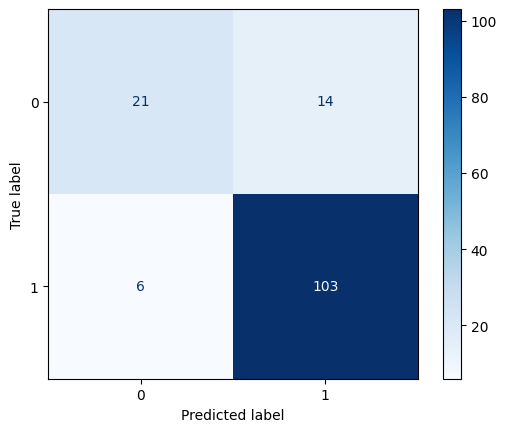

In [437]:
predRF = model1.predict(X_test)
repDT = classification_report(y_test, predRF)
print(repDT)

from imblearn.metrics import geometric_mean_score
print('G-mean =', geometric_mean_score(y_test, predRF))

disp = ConfusionMatrixDisplay.from_predictions(y_test, predRF, cmap = plt.cm.Blues)

# 0: Factores influyendo en el estado de salud. 1: Trastorno mental y del comportamiento.

**Matriz de confusión.**
* 21 + 103 = 124 aciertos.

* Porcentaje de aciertos → 124 / 144 = 0.86 → 86%.

* 6 + 14 = 20 errores.

**144 datos en total.**

**Reporte de clasificación.**
* 35 datos de prueba de **Factores influyendo en el estado de salud**.
    * 60% de positivos encontrados.
    * 78% fueron clasificados correctamente.

* 109 datos de prueba de **Trastorno mental y del comportamiento**.
    * 94% de positivos encontrados.
    * 88% fueron clasificados correctamente.

**F1-Score:** promedio ponderado de las clases.
* Factores influyendo en el estado de salud: 68%.
* Trastorno mental y del comportamiento: 91%.

Porcentaje de proporción a encontrar todas las clasificaciones de este estudio **(G-mean):** 75%.

**Este** porcentaje de proporción a encontrar todas las clasificaciones (G-mean) es el que queremos mejorar lo más que se pueda sin perjudicar a las clases de forma significativa con las técnicas de balanceo.

Las métricas de desempeño evaluadas para este modelo fueron:
* Accuracy.

* Matriz de confusión.

* G-mean.

* Precision.

* Recall (Sensibilidad).

* F1-Score.

**Random Forest Classifier - SMOTE.**

Procedemos a realizar el Random Forest Classifier con la técnica de balanceo de SMOTE, esta se escogió ya que fue la técnica con un mejor desempeño aunque genere datos sintéticos - esto es mejor que SMOTEENN que va a eliminar datos, escenario que en este caso no es factible ya que se tienen relativamente pocos datos con el dataset construido.

In [438]:
from imblearn.over_sampling import SMOTE

# Definir la técnica.
smote = SMOTE(random_state = 0)
# Aplicamos.
X_smote, y_smote = smote.fit_resample(X, y)

# Comprobar si funicona.
print('Tamaño de X antes de SMOTE:', X.shape)
print('Tamaño de X después de SMOTE:', X_smote.shape)
print('Balance de clases con SMOTE:', y_smote.value_counts())
print('Nuestras clases están balanceadas.')

Tamaño de X antes de SMOTE: (720, 3)
Tamaño de X después de SMOTE: (1094, 3)
Balance de clases con SMOTE: descripcion_grupo_enfermedad_num
1    547
0    547
Name: count, dtype: int64
Nuestras clases están balanceadas.


Separamos los datos en entrenamiento y prueba:

In [440]:
# Dividir los tratos en train y test.
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size = 0.2, random_state = 0, stratify = y_smote)
print(y_train.value_counts())
X_train.shape, X_test.shape, y_train.shape, y_test.shape
# No dividir de manera que se desbalanceen los datos -> cuidado con el random_state).

descripcion_grupo_enfermedad_num
1    438
0    437
Name: count, dtype: int64


((875, 3), (219, 3), (875,), (219,))

Definimos el modelo de Random Forest Classifier balanceado con los siguientes **hiperparámetros** principales:
* n_estimators: 100 → valor por default.

* criterion: Gini → definir la mejor regla de separación.

* max_depth: none → no existe límite para el crecimiento del bosque.

* class_weight: none → no se está aplicando ninguna técnica de balanceo que sea class_weight = 'balanced', sino que viene de una librería, no cuenta dentro de este criterio.

* random_state = 0 → según Sharma (2024), con esta condición, al momento de hacer el bootstrap se asegura que los datos se dividan igual en cada ocasión.

Son los mismos al Random Forest Classifier by Default.

In [439]:
# Definir el modelo balanceado.
model2 = RandomForestClassifier(random_state = 0)
# Entrenemos el modelo FS.
model2.fit(X_smote, y_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Validamos si el modelo pronostica adecuadamente:

In [441]:
# Validar si el modelo pronostica adecuadamente.
y_pred_test = model2.predict(X_test)
print(y_pred_test[0:5])
print(y_test.head())

[0 1 0 0 0]
944     0
199     1
1034    0
405     0
727     0
Name: descripcion_grupo_enfermedad_num, dtype: int64


5 aciertos de 5.

In [442]:
accuracy_train = model2.score(X_train, y_train)
print('Accuracy train = {:.2f}'.format(accuracy_train))
accuracy_test = model2.score(X_test, y_test)
print('Accuracy test = {:.2f}'.format(accuracy_test))
print('Diferencia = {:.4f}%'.format(np.abs(accuracy_train-accuracy_test)*100))

Accuracy train = 0.87
Accuracy test = 0.90
Diferencia = 2.7543%


Hasta este punto, obtenemos que el modelo balanceado también tiene un leve sobreajuste.

Sin embargo, su **Accuracy** de 90% apunta a que sabe generalizar muy bien entre los positivos reales y negativos reales (1 y 0 respectivamente). 

              precision    recall  f1-score   support

           0       0.89      0.91      0.90       110
           1       0.91      0.89      0.90       109

    accuracy                           0.90       219
   macro avg       0.90      0.90      0.90       219
weighted avg       0.90      0.90      0.90       219

G-mean = 0.8994484455794076


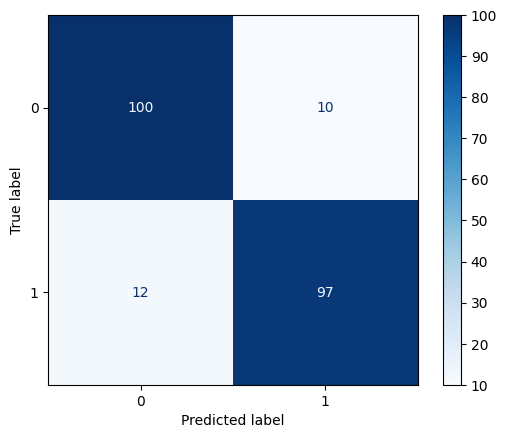

In [443]:
predRF = model2.predict(X_test)
repDT = classification_report(y_test, predRF)
print(repDT)

from imblearn.metrics import geometric_mean_score
print('G-mean =', geometric_mean_score(y_test, predRF))

disp = ConfusionMatrixDisplay.from_predictions(y_test, predRF, cmap = plt.cm.Blues)

# 0: Factores influyendo en el estado de salud. 1: Trastorno mental y del comportamiento.

**Matriz de confusión.**
* 100 + 97 = 197 aciertos.

* Porcentaje de aciertos → 197 / 219 = 0.89 → 89%.

* 12 + 10 = 22 errores.

**219 datos en total.**

**Reporte de clasificación.**
* 110 datos de prueba de **Factores influyendo en el estado de salud**.
    * 91% de positivos encontrados.
    * 89% fueron clasificados correctamente.

* 109 datos de prueba de **Trastorno mental y del comportamiento**.
    * 89% de positivos encontrados.
    * 91% fueron clasificados correctamente.

**F1-Score:** promedio ponderado de las clases.
* Factores influyendo en el estado de salud: 90%.
* Trastorno mental y del comportamiento: 90%.

Porcentaje de proporción a encontrar todas las clasificaciones de este estudio **(G-mean)**: 89%.

**Este** porcentaje de proporción a encontrar todas las clasificaciones (G-mean) mejora muchísimo una vez que tenemos las clases balanceadas, por lo que este tiene un buen rendimiento y mucho mejor al modelo no balanceado. 

Las métricas de desempeño evaluadas para este modelo fueron:
* Accuracy.

* Matriz de confusión.

* G-mean.

* Precision.

* Recall (Sensibilidad).

* F1-Score.

**Boosting - by Default.**

Procederemos a realizar el Boosting sin técnica de balanceo (se mencionó anteriormente su justificación).

In [444]:
# Definimos entrada y salida.
X = df2[['edad', 'sexo_num', 'institucion_unidad_medica_num']]
y = df2['descripcion_grupo_enfermedad_num']
print(X.shape)
print(y.shape)

(720, 3)
(720,)


Separamos los datos en entrenamiento y prueba:

In [445]:
# Dividir los tratos en train y test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0, stratify = y)
print(y_train.value_counts())
X_train.shape, X_test.shape, y_train.shape, y_test.shape

descripcion_grupo_enfermedad_num
1    438
0    138
Name: count, dtype: int64


((576, 3), (144, 3), (576,), (144,))

Definimos la construcción del árbol (diferente al Random Forest = bosque), esto mediante el DecisionTreeClassifier de sklearn.tree, sin balancear.

In [446]:
tree = DTC().fit(X_train, y_train)

Los **hiperparámetros** principales de este árbol son los siguientes:
* splitter: best → hacer las mejores separaciones (ramas) posibles.

* criterion: Gini → definir la mejor regla de separación.

* max_depth: none → no existe límite para el crecimiento del árbol.

* class_weight: none → no se está aplicando ninguna técnica de balanceo.

* random_state = 0 → según Sharma (2024), con esta condición, al momento de hacer el bootstrap se asegura que los datos se dividan igual en cada ocasión.

In [447]:
predDT = tree.predict(X_test)
accDT = accuracy_score(y_test, predDT)
f1DT = f1_score(y_test, predDT)
print("Accuracy de árbol de decisión:",accDT)
print("F1-score de árbol de decisión:",f1DT)

Accuracy de árbol de decisión: 0.8402777777777778
F1-score de árbol de decisión: 0.8959276018099548


El **Accuracy** del árbol es de 84%, concluimos que generaliza bien entre los positivos reales y negativos reales (1 y 0 respectivamente).

Su **F1-Score** en general es de 89%, esto indica que el árbol está bien equilibrado.

              precision    recall  f1-score   support

           0       0.69      0.63      0.66        35
           1       0.88      0.91      0.90       109

    accuracy                           0.84       144
   macro avg       0.79      0.77      0.78       144
weighted avg       0.84      0.84      0.84       144

G-mean = 0.7555821100534114


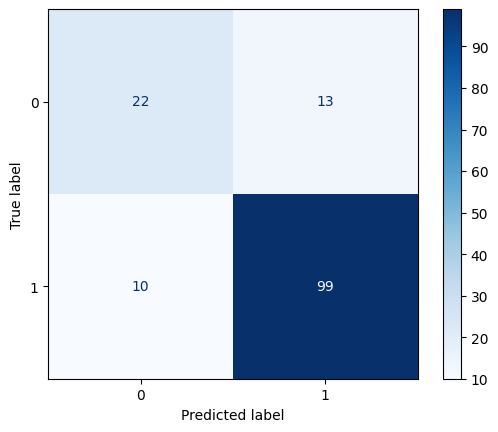

In [448]:
predDT = tree.predict(X_test)
repDT = classification_report(y_test, predDT)
print(repDT)

from imblearn.metrics import geometric_mean_score
print('G-mean =', geometric_mean_score(y_test, predDT))

disp = ConfusionMatrixDisplay.from_predictions(y_test, predDT, cmap = plt.cm.Blues)

# 0: Factores influyendo en el estado de salud. 1: Trastorno mental y del comportamiento.

**Matriz de confusión.**
* 21 + 103 = 121 aciertos.

* Porcentaje de aciertos → 121 / 144 = 0.84 → 84%.

* 10 + 13 = 23 errores.

**144 datos en total.**

**Reporte de clasificación.**
* 35 datos de prueba de **Factores influyendo en el estado de salud**.
    * 63% de positivos encontrados.
    * 69% fueron clasificados correctamente.

* 109 datos de prueba de **Trastorno mental y del comportamiento**.
    * 91% de positivos encontrados.
    * 88% fueron clasificados correctamente.

**F1-Score:** promedio ponderado de las clases.
* Factores influyendo en el estado de salud: 66%.
* Trastorno mental y del comportamiento: 90%.

Porcentaje de proporción a encontrar todas las clasificaciones de este estudio **(G-mean):** 75%.

**Este** porcentaje de proporción a encontrar todas las clasificaciones (G-mean) es el que queremos mejorar lo más que se pueda sin perjudicar a las clases de forma significativa con las técnicas de balanceo.

Las métricas de desempeño evaluadas para este modelo fueron:
* Accuracy.

* Matriz de confusión.

* G-mean.

* Precision.

* Recall (Sensibilidad).

* F1-Score.

**Boosting - SMOTE.**

Procederemos a realizar el Boosting con la técnica de balanceo de SMOTE (se mencionó anteriormente su justificación).

In [449]:
from imblearn.over_sampling import SMOTE

# Definir la técnica.
smote = SMOTE(random_state = 0)
# Aplicamos.
X_smote, y_smote = smote.fit_resample(X, y)

# Comprobar si funicona.
print('Tamaño de X antes de SMOTE:', X.shape)
print('Tamaño de X después de SMOTE:', X_smote.shape)
print('Balance de clases con SMOTE:', y_smote.value_counts())
print('Nuestras clases están balanceadas.')

Tamaño de X antes de SMOTE: (720, 3)
Tamaño de X después de SMOTE: (1094, 3)
Balance de clases con SMOTE: descripcion_grupo_enfermedad_num
1    547
0    547
Name: count, dtype: int64
Nuestras clases están balanceadas.


Separamos los datos en entrenamiento y prueba:

In [450]:
# Dividir los tratos en train y test.
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size = 0.2, random_state = 0, stratify = y_smote)
print(y_train.value_counts())
X_train.shape, X_test.shape, y_train.shape, y_test.shape
# No dividir de manera que se desbalanceen los datos -> cuidado con el random_state).

descripcion_grupo_enfermedad_num
1    438
0    437
Name: count, dtype: int64


((875, 3), (219, 3), (875,), (219,))

Los **hiperparámetros** principales de este árbol son los siguientes:
* splitter: best → hacer las mejores separaciones (ramas) posibles.

* criterion: Gini → definir la mejor regla de separación.

* max_depth: none → no existe límite para el crecimiento del árbol.

* class_weight: none → no se está aplicando ninguna técnica de balanceo que sea class_weight = 'balanced', sino que viene de una librería, no cuenta dentro de este criterio.

* random_state = 0 → según Sharma (2024), con esta condición, al momento de hacer el bootstrap se asegura que los datos se dividan igual en cada ocasión.

Son los mismos al Boosting by Default.

Definimos nuevamente la construcción del árbol (diferente al Random Forest = bosque), esto mediante el DecisionTreeClassifier de sklearn.tree, ahora balanceado.

In [451]:
tree = DTC().fit(X_train, y_train)

In [452]:
predDT = tree.predict(X_test)
accDT = accuracy_score(y_test, predDT)
f1DT = f1_score(y_test, predDT)
print("Accuracy de árbol de decisión:",accDT)
print("F1-score de árbol de decisión:",f1DT)

Accuracy de árbol de decisión: 0.8858447488584474
F1-score de árbol de decisión: 0.8815165876777251


El **Accuracy** del árbol es de 88% (casi 89%), concluimos que generaliza mejor que el modelo by Default entre los positivos reales y negativos reales (1 y 0 respectivamente).

Su **F1-Score** en general es de 88%, esto indica que el árbol está bien equilibrado, aunque este valor es menor en comparación al modelo by Default.

              precision    recall  f1-score   support

           0       0.86      0.92      0.89       110
           1       0.91      0.85      0.88       109

    accuracy                           0.89       219
   macro avg       0.89      0.89      0.89       219
weighted avg       0.89      0.89      0.89       219



G-mean = 0.8851004664423207


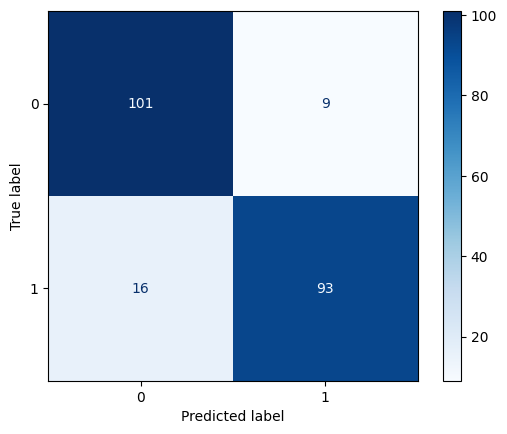

In [453]:
predDT = tree.predict(X_test)
repDT = classification_report(y_test, predDT)
print(repDT)

from imblearn.metrics import geometric_mean_score
print('G-mean =', geometric_mean_score(y_test, predDT))

disp = ConfusionMatrixDisplay.from_predictions(y_test, predDT, cmap = plt.cm.Blues)

# 0: Factores influyendo en el estado de salud. 1: Trastorno mental y del comportamiento.

**Matriz de confusión.**
* 101 + 93 = 194 aciertos.

* Porcentaje de aciertos → 194 / 219 = 0.88 → 88%.

* 16 + 9 = 25 errores.

**219 datos en total.**

**Reporte de clasificación.**
* 110 datos de prueba de **Factores influyendo en el estado de salud**.
    * 92% de positivos encontrados.
    * 86% fueron clasificados correctamente.

* 109 datos de prueba de **Trastorno mental y del comportamiento**.
    * 85% de positivos encontrados.
    * 91% fueron clasificados correctamente.

**F1-Score:** promedio ponderado de las clases.
* Factores influyendo en el estado de salud: 89%.
* Trastorno mental y del comportamiento: 88%.

Porcentaje de proporción a encontrar todas las clasificaciones de este estudio **(G-mean):** 88%.

**Este** porcentaje de proporción a encontrar todas las clasificaciones (G-mean) mejora muchísimo una vez que tenemos las clases balanceadas, por lo que este tiene un buen rendimiento y mucho mejor al modelo no balanceado. 

Las métricas de desempeño evaluadas para este modelo fueron:
* Accuracy.

* Matriz de confusión.

* G-mean.

* Precision.

* Recall (Sensibilidad).

* F1-Score.

**SVM - by Default.**

Procederemos a realizar el Support Vector Machine (SVM) sin técnica de balanceo (se mencionó anteriormente su justificación), esto con la guía oficial de sklearn según 1.4. Support Vector Machines (s. f.).

Aquí importamos de la librería de sklearn la Support Vector Machine.

In [ ]:
from sklearn.svm import SVC

# Definimos entrada y salida.
X = df2[['edad', 'sexo_num', 'institucion_unidad_medica_num']]
y = df2['descripcion_grupo_enfermedad_num']

Separamos los datos en entrenamiento y prueba:

In [455]:
# Dividimos en train y test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0, stratify = y)
print(y_train.value_counts())
X_train.shape, X_test.shape

descripcion_grupo_enfermedad_num
1    438
0    138
Name: count, dtype: int64


((576, 3), (144, 3))

En este punto vale la pena mencionar que se utilizará un escalador de características, siendo en este caso en StandardScaler. 

Según Aylin Tokuç (2025), este escalado de características consiste en asignar los valores de las características de un conjunto de datos al mismo rango - es crucial para algoritmos como el SVM ya que este **considera las distancias entre observaciones (margen)**, dicha distancia difiere entre los datos sin escalar a aquellos escalados, aparte de la sensibilidad en las características.

In [456]:
# Escalamos las características (recomendado para SVM).
scaler_svm = StandardScaler()
X_train_svm = scaler_svm.fit_transform(X_train)
X_test_svm = scaler_svm.transform(X_test)

Definimos el modelo de SVM sin balancear con los siguientes **hiperparámetros** principales:
* C: 1 → penalización proporcional al valor absoluto de los coeficientes del modelo.

* kernel: rbf → definir la mejor regla de separación.

* degree: 3 → grado del kernel.

* gamma: scale → coeficiente del kernel.

* class_weight: none → no se está aplicando ninguna técnica de balanceo.

In [457]:
# Definir el modelo by Default.
model_svm1 = SVC(kernel = 'rbf', random_state = 0)
# Entrenemos el modelo SVM.
model_svm1.fit(X_train_svm, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [458]:
accuracy_train_svm1 = model_svm1.score(X_train_svm, y_train)
print('Accuracy train = {:.2f}'.format(accuracy_train_svm1))
accuracy_test_svm1 = model_svm1.score(X_test_svm, y_test)
print('Accuracy test = {:.2f}'.format(accuracy_test_svm1))
print('Diferencia = {:.4f}%'.format(np.abs(accuracy_train_svm1-accuracy_test_svm1)*100))

Accuracy train = 0.79
Accuracy test = 0.81
Diferencia = 1.9097%


El modelo tiene un pequeño sobreajuste.

Su **Accuracy** de 81% apunta a que sabe generalizar bien entre los positivos reales y negativos reales (1 y 0 respectivamente), sin embargo, puede aún mejorar.

              precision    recall  f1-score   support

           0       0.64      0.51      0.57        35
           1       0.85      0.91      0.88       109

    accuracy                           0.81       144
   macro avg       0.75      0.71      0.73       144
weighted avg       0.80      0.81      0.81       144

G-mean = 0.6834497338233234


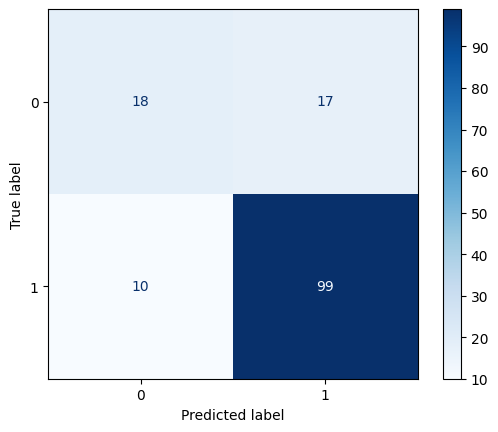

In [459]:
pred_svm1 = model_svm1.predict(X_test_svm)
rep_svm1 = classification_report(y_test, pred_svm1)
print(rep_svm1)

from imblearn.metrics import geometric_mean_score
print('G-mean =', geometric_mean_score(y_test, pred_svm1))

disp = ConfusionMatrixDisplay.from_predictions(y_test, pred_svm1, cmap = plt.cm.Blues)

# 0: Factores influyendo en el estado de salud. 1: Trastorno mental y del comportamiento.

**Matriz de confusión.**
* 18 + 99 = 117 aciertos.

* Porcentaje de aciertos → 124 / 144 = 0.86 → 86%.

* 10 + 17 = 27 errores.

**144 datos en total.**

**Reporte de clasificación.**
* 35 datos de prueba de **Factores influyendo en el estado de salud**.
    * 51% de positivos encontrados.
    * 64% fueron clasificados correctamente.

* 109 datos de prueba de **Trastorno mental y del comportamiento**.
    * 91% de positivos encontrados.
    * 85% fueron clasificados correctamente.

**F1-Score:** promedio ponderado de las clases.
* Factores influyendo en el estado de salud: 57%.
* Trastorno mental y del comportamiento: 88%.

Porcentaje de proporción a encontrar todas las clasificaciones de este estudio **(G-mean):** 68%.

**Este** porcentaje de proporción a encontrar todas las clasificaciones (G-mean) es el que queremos mejorar lo más que se pueda sin perjudicar a las clases de forma significativa con las técnicas de balanceo.

Las métricas de desempeño evaluadas para este modelo fueron:
* Accuracy.

* Matriz de confusión.

* G-mean.

* Precision.

* Recall (Sensibilidad).

* F1-Score.

**SVM - SMOTE.**

Procederemos a realizar el SVM con la técnica de balanceo de SMOTE (se mencionó anteriormente su justificación), esto con la guía oficial de sklearn según 1.4. Support Vector Machines (s. f.).

In [460]:
from imblearn.over_sampling import SMOTE

# Aplicamos SMOTE sobre los datos originales.
smote = SMOTE(random_state=0)
X_smote_svm, y_smote_svm = smote.fit_resample(X, y)

print('Tamaño de X antes de SMOTE:', X.shape)
print('Tamaño de X después de SMOTE:', X_smote_svm.shape)
print('Balance de clases con SMOTE:')
print(y_smote_svm.value_counts())
print('Nuestras clases están balanceadas.')

Tamaño de X antes de SMOTE: (720, 3)
Tamaño de X después de SMOTE: (1094, 3)
Balance de clases con SMOTE:
descripcion_grupo_enfermedad_num
1    547
0    547
Name: count, dtype: int64
Nuestras clases están balanceadas.


Separamos los datos en entrenamiento y prueba:

In [461]:
# Dividir los datos balanceados en train y test.
X_train, X_test, y_train, y_test = train_test_split(X_smote_svm, y_smote_svm, test_size=0.2, random_state=0, stratify=y_smote_svm)
print(y_train.value_counts())
X_train.shape, X_test.shape

descripcion_grupo_enfermedad_num
1    438
0    437
Name: count, dtype: int64


((875, 3), (219, 3))

Seguimos con SVM, aunque utilicemos la técnica de balanceo de SMOTE, todavía se aplica el escalador StandardScaler.

In [462]:
# Escalamos las características.
scaler_svm2 = StandardScaler()
X_train_svm2 = scaler_svm2.fit_transform(X_train)
X_test_svm2 = scaler_svm2.transform(X_test)

Definimos el modelo de SVM balanceado con los siguientes **hiperparámetros** principales:
* C: 1 → penalización proporcional al valor absoluto de los coeficientes del modelo.

* kernel: rbf → definir la mejor regla de separación.

* degree: 3 → grado del kernel.

* gamma: scale → coeficiente del kernel.

* class_weight: none → no se está aplicando ninguna técnica de balanceo.

In [463]:
# Definir el modelo balanceado.
model_svm2 = SVC(kernel = 'rbf', random_state = 0)
# Entrenemos el modelo SVM.
model_svm2.fit(X_train_svm2, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [464]:
# Evaluación del modelo SVM balanceado.
accuracy_train_svm2 = model_svm2.score(X_train_svm2, y_train)
print('Accuracy train = {:.2f}'.format(accuracy_train_svm2))
accuracy_test_svm2 = model_svm2.score(X_test_svm2, y_test)
print('Accuracy test = {:.2f}'.format(accuracy_test_svm2))
print('Diferencia = {:.4f}%'.format(np.abs(accuracy_train_svm2-accuracy_test_svm2)*100))

Accuracy train = 0.75
Accuracy test = 0.75
Diferencia = 0.8282%


El modelo tiene un muy pequeño sobreajuste.

Su **Accuracy** de 75% apunta a que sabe generalizar entre los positivos reales y negativos reales (1 y 0 respectivamente), sin embargo, puede aún mejorar en gran escala ya que en otros modelos llego hasta el 80%.

              precision    recall  f1-score   support

           0       0.73      0.82      0.77       110
           1       0.79      0.69      0.74       109

    accuracy                           0.75       219
   macro avg       0.76      0.75      0.75       219
weighted avg       0.76      0.75      0.75       219

G-mean = 0.7503126954482326


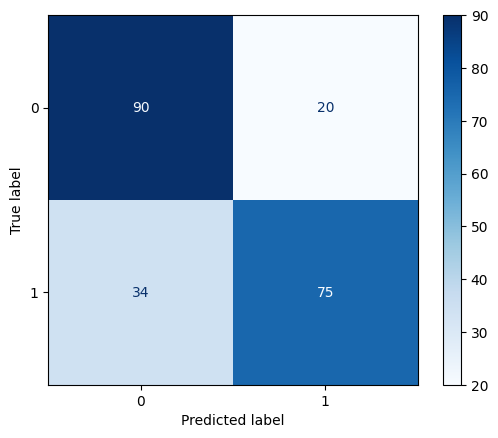

In [465]:
pred_svm2 = model_svm2.predict(X_test_svm2)
rep_svm2 = classification_report(y_test, pred_svm2)
print(rep_svm2)

print('G-mean =', geometric_mean_score(y_test, pred_svm2))

disp = ConfusionMatrixDisplay.from_predictions(y_test, pred_svm2, cmap = plt.cm.Blues)

# 0: Factores influyendo en el estado de salud. 1: Trastorno mental y del comportamiento.

**Matriz de confusión.**
* 90 + 75 = 165 aciertos.

* Porcentaje de aciertos → 165 / 219 = 0.86 → 75%.

* 34 + 20 = 54 errores.

**219 datos en total.**

**Reporte de clasificación.**
* 110 datos de prueba de **Factores influyendo en el estado de salud**.
    * 82% de positivos encontrados.
    * 73% fueron clasificados correctamente.

* 109 datos de prueba de **Trastorno mental y del comportamiento**.
    * 69% de positivos encontrados.
    * 79% fueron clasificados correctamente.

**F1-Score:** promedio ponderado de las clases.
* Factores influyendo en el estado de salud: 77%.
* Trastorno mental y del comportamiento: 74%.

Porcentaje de proporción a encontrar todas las clasificaciones de este estudio **(G-mean):** 75%.

**Este** porcentaje de proporción a encontrar todas las clasificaciones (G-mean) es el que queremos mejorar lo más que se pueda sin perjudicar a las clases de forma significativa con las técnicas de balanceo (refutando a la idea del Accuray anteriormente).

Las métricas de desempeño evaluadas para este modelo fueron:
* Accuracy.

* Matriz de confusión.

* G-mean.

* Precision.

* Recall (Sensibilidad).

* F1-Score.

**Red Neuronal.**

Construcción de Red Neuronal según Persson (2020).

In [466]:
# Activación y perdida.
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1/(1+np.exp(-np.clip(z, -500, 500)))

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8
    return -np.mean(y_true*np.log(y_pred+eps)+(1-y_true)*np.log(1 - y_pred+eps))


# Generación de la Red Neuronal.
class RedNeuronal:
    """Red neuronal binaria de una capa oculta construida desde cero con NumPy."""

    def __init__(self, n_entrada = 3, n_oculta = 6, lr = 0.01, epochs = 1000, random_state = 0):
        self.n_entrada = n_entrada
        self.n_oculta = n_oculta
        self.lr = lr
        self.epochs = epochs
        self.random_state = random_state
        self.losses = []

    def _init_params(self):
        rng = np.random.default_rng(self.random_state)
        # He initialization (recomendada para ReLU).
        self.W1 = rng.standard_normal((self.n_entrada, self.n_oculta))*np.sqrt(2/self.n_entrada)
        self.b1 = np.zeros((1, self.n_oculta))
        self.W2 = rng.standard_normal((self.n_oculta, 1))*np.sqrt(2/self.n_oculta)
        self.b2 = np.zeros((1, 1))

    def _forward(self, X):
        self.Z1 = X @ self.W1+self.b1 # (n, n_oculta).
        self.A1 = relu(self.Z1) # (n, n_oculta).
        self.Z2 = self.A1 @ self.W2+self.b2 # (n, 1).
        self.A2 = sigmoid(self.Z2) # (n, 1).
        return self.A2

    def _backward(self, X, y):
        n = X.shape[0]
        # Gradiente capa de salida.
        dZ2 = self.A2-y # (n, 1).
        dW2 = (self.A1.T @ dZ2)/n
        db2 = np.mean(dZ2, axis = 0, keepdims = True)
        # Gradiente capa oculta.
        dA1 = dZ2 @ self.W2.T # (n, n_oculta).
        dZ1 = dA1*relu_deriv(self.Z1)
        dW1 = (X.T @ dZ1)/n
        db1 = np.mean(dZ1, axis = 0, keepdims = True)
        # Actualizar pesos.
        self.W2 -= self.lr*dW2
        self.b2 -= self.lr*db2
        self.W1 -= self.lr*dW1
        self.b1 -= self.lr*db1

    def fit(self, X, y):
        self._init_params()
        y = y.reshape(-1, 1).astype(float)
        for epoch in range(self.epochs):
            y_pred = self._forward(X)
            loss = binary_cross_entropy(y, y_pred)
            self.losses.append(loss)
            self._backward(X, y)
            if (epoch+1)%200 == 0:
                print(f'Epoch {epoch+1}/{self.epochs}  |  Loss: {loss:.4f}')
        return self

    def predict_proba(self, X):
        return self._forward(X).flatten()

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

    def plot_loss(self, title='Curva de pérdida'):
        plt.figure(figsize=(7, 3))
        plt.plot(self.losses)
        plt.xlabel('Época')
        plt.ylabel('Binary Cross-Entropy')
        plt.title(title)
        plt.tight_layout()
        plt.show()

print('Clase RedNeuronal definida correctamente.')

Clase RedNeuronal definida correctamente.


Al momento de generar la clase de la Red Neuronal, se utilizaran 6 neuronas, esto debido a que se sigue la regla de 2 * entradas, resultando en:

2 * 3 = 6 → 6 neuronas.

**Red Neuronal - by Default.**

Procederemos a realizar la Red Neuronal sin técnica de balanceo (se mencionó anteriormente su justificación).

Definimos variables:

In [ ]:
# Definimos entrada y salida.
X = df2[['edad', 'sexo_num', 'institucion_unidad_medica_num']]
y = df2['descripcion_grupo_enfermedad_num']

Separamos los datos en entrenamiento y prueba:

In [468]:
# Dividimos en train y test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
print(y_train.value_counts())
X_train.shape, X_test.shape

descripcion_grupo_enfermedad_num
1    438
0    138
Name: count, dtype: int64


((576, 3), (144, 3))

Nuevamente, se utilizará un escalador de características, siendo el mismo de StandardScaler. Esto sucede debido a que la red neuronal repite el patrón de características en SVM de la sensibilidad, solo que en este caso sucede (a diferencia de margen) por el gradiente descendente.

In [469]:
# Escalamos las características (necesario para la red neuronal).
scaler_nn1 = StandardScaler()
X_train_nn1 = scaler_nn1.fit_transform(X_train)
X_test_nn1 = scaler_nn1.transform(X_test)

Los **hiperparámetros** principales de la red neuronal son los siguientes:
* n_entrada: 3 → número de variables independientes (edad, sexo_num, institucion_unidad_medica_num).

* n_oculta: 6 → neuronas en la capa oculta, calculadas con la regla 2 × n_entrada = 2 × 3 = 6. Este valor otorga mayor capacidad de aprendizaje que las recomendaciones mínimas, sin riesgo significativo de sobreajuste dado el tamaño del dataset.

* lr (learning rate): 0.01 → tasa de aprendizaje conservadora que permite convergencia estable sin saltar mínimos.

* epochs: 1000 → número de iteraciones de entrenamiento suficientes para observar convergencia en la curva de pérdida.

* Función de activación capa oculta: ReLU → eficiente y estable, evita el problema del gradiente desvaneciente.

* Función de activación capa de salida: Sigmoide → adecuada para clasificación binaria, produce probabilidades entre 0 y 1.

* Función de pérdida: Binary Cross-Entropy → estándar para clasificación binaria.

* Inicialización de pesos: He initialization → recomendada cuando se usa ReLU, mejora la convergencia.

* class_weight: none → no se está aplicando ninguna técnica de balanceo.

In [ ]:
# Definir el modelo by Default.
model_nn1 = RedNeuronal(n_entrada = 3, n_oculta = 6, lr = 0.01, epochs = 1000, random_state = 0)
# Entrenamos el modelo.
model_nn1.fit(X_train_nn1, y_train.values)

Epoch 200/1000  |  Loss: 0.4644
Epoch 400/1000  |  Loss: 0.4563
Epoch 600/1000  |  Loss: 0.4531
Epoch 800/1000  |  Loss: 0.4518
Epoch 1000/1000  |  Loss: 0.4511


Curva de pérdida:

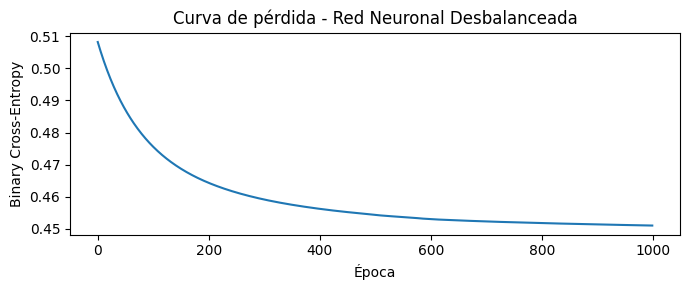

In [471]:
# Curva de pérdida.
model_nn1.plot_loss(title='Curva de pérdida - Red Neuronal Desbalanceada')

La curva indica que el modelo disminuye a lo largo de las épocas del entrenamiento.

In [472]:
# Evaluación del modelo.
accuracy_train_nn1 = model_nn1.score(X_train_nn1, y_train.values)
print('Accuracy train = {:.2f}'.format(accuracy_train_nn1))
accuracy_test_nn1 = model_nn1.score(X_test_nn1, y_test.values)
print('Accuracy test = {:.2f}'.format(accuracy_test_nn1))
print('Diferencia = {:.4f}%'.format(np.abs(accuracy_train_nn1-accuracy_test_nn1)*100))

Accuracy train = 0.76
Accuracy test = 0.76
Diferencia = 0.3472%


El modelo tiene un muy pequeño sobreajuste.

Su **Accuracy** de 76% apunta a que sabe generalizar entre los positivos reales y negativos reales (1 y 0 respectivamente), sin embargo, puede aún mejorar en gran escala ya que en otros modelos llego hasta el 80%.

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        35
           1       0.76      1.00      0.86       109

    accuracy                           0.76       144
   macro avg       0.38      0.50      0.43       144
weighted avg       0.57      0.76      0.65       144

G-mean = 0.0


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


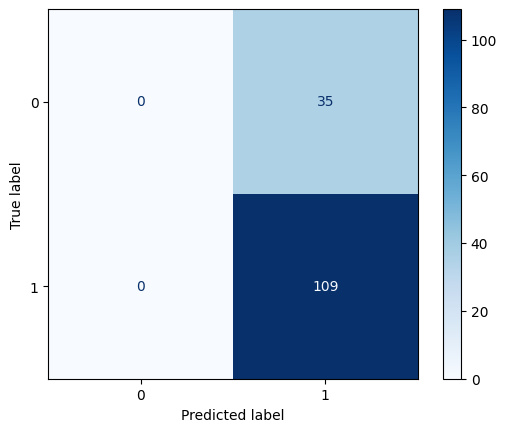

In [473]:
pred_nn1 = model_nn1.predict(X_test_nn1)
rep_nn1  = classification_report(y_test, pred_nn1)
print(rep_nn1)

print('G-mean =', geometric_mean_score(y_test, pred_nn1))

disp = ConfusionMatrixDisplay.from_predictions(y_test, pred_nn1, cmap = plt.cm.Blues)

# 0: Factores influyendo en el estado de salud. 1: Trastorno mental y del comportamiento.

**Matriz de confusión.**
* 0 + 109 = 109 aciertos.

* Porcentaje de aciertos → 109 / 144 = 0.76 → 76%.

* 35 + 0 = 35 errores.

**144 datos en total.**

**Reporte de clasificación.**
* 35 datos de prueba de **Factores influyendo en el estado de salud**.
    * 0% de positivos encontrados.
    * 0% fueron clasificados correctamente.

* 109 datos de prueba de **Trastorno mental y del comportamiento**.
    * 100% de positivos encontrados.
    * 76% fueron clasificados correctamente.

**F1-Score:** promedio ponderado de las clases.
* Factores influyendo en el estado de salud: 0%.
* Trastorno mental y del comportamiento: 86%.

Porcentaje de proporción a encontrar todas las clasificaciones de este estudio **(G-mean):** 0%.

**Este** G-mean de 0 es el resultado más revelador: la red neuronal sin balanceo aprendió a predecir siempre la clase mayoritaria (Trastorno mental y del comportamiento), ignorando por completo la clase minoritaria. Esto confirma que el desbalanceo de clases afecta severamente a las redes neuronales construidas desde cero, ya que el gradiente descendente optimiza la pérdida global sin considerar la representación de cada clase.

Las métricas de desempeño evaluadas para este modelo fueron:
* Accuracy.

* Matriz de confusión.

* G-mean.

* Precision.

* Recall (Sensibilidad).

* F1-Score.

* Curva de pérdida.

**Red Neuronal - SMOTE.**

Procederemos a realizar la Red Neuronal con la técnica de balanceo de SMOTE (se mencionó anteriormente su justificación).

In [474]:
from imblearn.over_sampling import SMOTE

# Aplicamos SMOTE sobre los datos originales.
smote = SMOTE(random_state=0)
X_smote_nn, y_smote_nn = smote.fit_resample(X, y)

print('Tamaño de X antes de SMOTE:', X.shape)
print('Tamaño de X después de SMOTE:', X_smote_nn.shape)
print('Balance de clases con SMOTE:')
print(y_smote_nn.value_counts())
print('Nuestras clases están balanceadas.')

Tamaño de X antes de SMOTE: (720, 3)
Tamaño de X después de SMOTE: (1094, 3)
Balance de clases con SMOTE:
descripcion_grupo_enfermedad_num
1    547
0    547
Name: count, dtype: int64
Nuestras clases están balanceadas.


Separamos los datos en entrenamiento y prueba:

In [475]:
# Dividir los datos balanceados en train y test.
X_train, X_test, y_train, y_test = train_test_split(X_smote_nn, y_smote_nn, test_size = 0.2, random_state = 0, stratify = y_smote_nn)
print(y_train.value_counts())
X_train.shape, X_test.shape

descripcion_grupo_enfermedad_num
1    438
0    437
Name: count, dtype: int64


((875, 3), (219, 3))

Repetimos el escalador StandardScaler:

In [476]:
# Escalamos las características.
scaler_nn2 = StandardScaler()
X_train_nn2 = scaler_nn2.fit_transform(X_train)
X_test_nn2 = scaler_nn2.transform(X_test)

Los **hiperparámetros** principales de la red neuronal son los siguientes:
* n_entrada: 3 → número de variables independientes (edad, sexo_num, institucion_unidad_medica_num).

* n_oculta: 6 → neuronas en la capa oculta, calculadas con la regla 2 × n_entrada = 2 × 3 = 6. Este valor otorga mayor capacidad de aprendizaje que las recomendaciones mínimas, sin riesgo significativo de sobreajuste dado el tamaño del dataset.

* lr (learning rate): 0.01 → tasa de aprendizaje conservadora que permite convergencia estable sin saltar mínimos.

* epochs: 1000 → número de iteraciones de entrenamiento suficientes para observar convergencia en la curva de pérdida.

* Función de activación capa oculta: ReLU → eficiente y estable, evita el problema del gradiente desvaneciente.

* Función de activación capa de salida: Sigmoide → adecuada para clasificación binaria, produce probabilidades entre 0 y 1.

* Función de pérdida: Binary Cross-Entropy → estándar para clasificación binaria.

* Inicialización de pesos: He initialization → recomendada cuando se usa ReLU, mejora la convergencia.

* class_weight: none → no se está aplicando ninguna técnica de balanceo.

Son los mismos al modelo de Red Neuronal by Default.

In [ ]:
# Definir el modelo balanceado.
model_nn2 = RedNeuronal(n_entrada = 3, n_oculta = 6, lr = 0.01, epochs = 1000, random_state = 0)
# Entrenemos el modelo.
model_nn2.fit(X_train_nn2, y_train.values)

Epoch 200/1000  |  Loss: 0.5910
Epoch 400/1000  |  Loss: 0.5781
Epoch 600/1000  |  Loss: 0.5706
Epoch 800/1000  |  Loss: 0.5658
Epoch 1000/1000  |  Loss: 0.5624


Curva de pérdida:

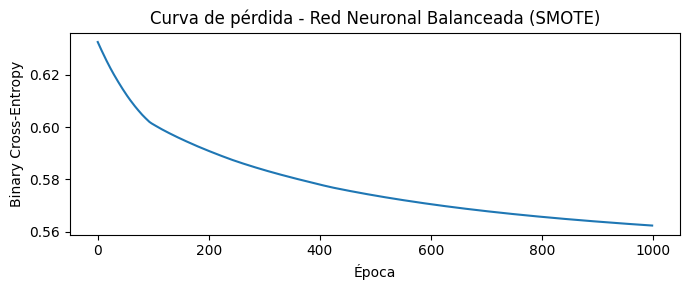

In [478]:
# Curva de pérdida.
model_nn2.plot_loss(title='Curva de pérdida - Red Neuronal Balanceada (SMOTE)')

Nuevamente, la curva de pérdida va disminuyendo a lo largo del entrenamiento.

In [479]:
# Evaluación del modelo.
accuracy_train_nn2 = model_nn2.score(X_train_nn2, y_train.values)
print('Accuracy train = {:.2f}'.format(accuracy_train_nn2))
accuracy_test_nn2 = model_nn2.score(X_test_nn2, y_test.values)
print('Accuracy test = {:.2f}'.format(accuracy_test_nn2))
print('Diferencia = {:.4f}%'.format(np.abs(accuracy_train_nn2-accuracy_test_nn2)*100))

Accuracy train = 0.72
Accuracy test = 0.74
Diferencia = 2.6578%


El modelo tiene un pequeño sobreajuste.

Su **Accuracy** de 74% apunta a que sabe generalizar entre los positivos reales y negativos reales (1 y 0 respectivamente), sin embargo, puede aún mejorar en gran escala ya que en otros modelos llego hasta el 80%.

              precision    recall  f1-score   support

           0       0.72      0.80      0.76       110
           1       0.77      0.69      0.73       109

    accuracy                           0.74       219
   macro avg       0.75      0.74      0.74       219
weighted avg       0.75      0.74      0.74       219

G-mean = 0.7419290502442469


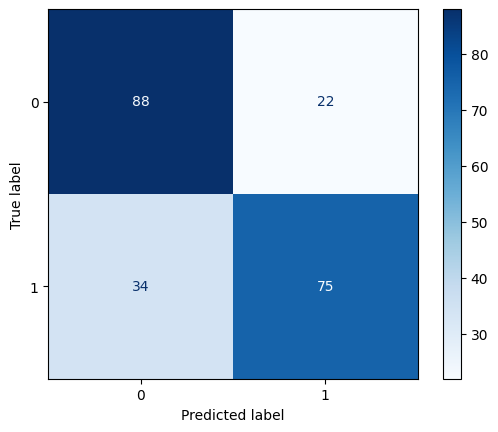

In [480]:
pred_nn2 = model_nn2.predict(X_test_nn2)
rep_nn2  = classification_report(y_test, pred_nn2)
print(rep_nn2)

print('G-mean =', geometric_mean_score(y_test, pred_nn2))

disp = ConfusionMatrixDisplay.from_predictions(y_test, pred_nn2, cmap = plt.cm.Blues)

# 0: Factores influyendo en el estado de salud. 1: Trastorno mental y del comportamiento.

**Matriz de confusión.**
* 88 + 75 = 163 aciertos.

* Porcentaje de aciertos → 163 / 219 = 0.76 → 74%.

* 34 + 22 = 56 errores.

**219 datos en total.**

**Reporte de clasificación.**
* 110 datos de prueba de **Factores influyendo en el estado de salud**.
    * 80% de positivos encontrados.
    * 72% fueron clasificados correctamente.

* 109 datos de prueba de **Trastorno mental y del comportamiento**.
    * 69% de positivos encontrados.
    * 77% fueron clasificados correctamente.

**F1-Score:** promedio ponderado de las clases.
* Factores influyendo en el estado de salud: 76%.
* Trastorno mental y del comportamiento: 73%.

Porcentaje de proporción a encontrar todas las clasificaciones de este estudio **(G-mean):** 74%.

**Este** G-mean mejora mucho a comparación del obtenido con el modelo by Default, con esto podemos reafirmar la importancia de la técnica de balanceo, en este caso siendo la de SMOTE.

Las métricas de desempeño evaluadas para este modelo fueron:
* Accuracy.

* Matriz de confusión.

* G-mean.

* Precision.

* Recall (Sensibilidad).

* F1-Score.

* Curva de pérdida.

# 5.1 Evaluación de los modelos.

Para evaluar los modelos de:
* Random Forest.

* Boosting.

* Support Vector Machine (SVM).

* Red Neuronal.

Tanto desbalanceado (by Default), como balanceado (SMOTE), se presenta la siguiente tabla comparativa:
| Modelo | Escenario | Accuracy | G-mean | F1 Clase 0 | F1 Clase 1 |
|---|---|---|---|---|---|
| Random Forest | Desbalanceado | 86% | 75% | 68% | 91% |
| Random Forest | SMOTE | 89% | 89% | 90% | 90% |
| Boosting | Desbalanceado | 84% | 75% | 66% | 90% |
| Boosting | SMOTE | 88% | 88% | 89% | 88% |
| SVM | Desbalanceado | 81% | 68% | 57% | 88% |
| SVM | SMOTE | 75% | 75% | 77% | 74% |
| Red Neuronal | Desbalanceado | 76% | 0% | 0% | 86% |
| Red Neuronal | SMOTE | 74% | 74% | 76% | 73% |

El mejor modelo de todos es el: **Random Forest con SMOTE**, es decir, un bosque balanceado.

Esto se debe a que además de presentar los mejores resultados:
* Accuracy: 89%.

* G-mean: 89%.

* F1-Score de clase 0: 90%.

* F1-Score de clase 1: 90%.

Además, que por el hecho de el Random Forest ser un modelo cuyos árboles no presentan una alta correlación, permite la exploración a profundidad de la base de datos, generándo insights valiosos que otros modelos no logran descifrar. 

Podemos concluir de dicho modelo que es el que mejor puede predecir si un individuo padece de un trastorno mental que requiere de un seguimiento profesional o si solo requiere de una terapia sin necesidad de un tratamiento guiado - cumpliendo justo con lo que se quería desde que se estableció el objetivo.

# 6.1 Discusiones.

Para este proyecto, se presentaron dificultades a la hora de desarrollar el modelo de Red Neuronal, ya que el mismo no proviene de una librería, sino que se tiene que construir el mismo desde cero. Sin embargo, con los recursos de internet fue que se pudo construir el mismo sin problema.

# 7.1 Conclusiones.

Para concluir, el realizar cada uno de estos modelos de forma desbalanceada y balanceada, permite conocer como la técnica de balanceo es muy necesaria cuando estamos trabajando con clases desbalanceadas, reafirmando la importancia de evitar el sesgo por una clase mayoritaría.

Este balance mediante la técnica de SMOTE mejoró el desempeño de todos los modelos evaluados, sin embargo, fue el de Random Forest aplicado con este que brinda las mejores métricas, que esto indica su poder predictivo para el escenario planteado de la salud mental de los adultos económicamente activos en el municipio de San Pedro Garza García.

Vale la pena también mencionar que la Red Neuronal mostró ser muy sensible al desbalance de las clases, algo que vale la pena tener en consideración para la futura construcción de otras Redes Neuronales, sea con 2 o más clases - probando diversas técnicas para encontrar la mejor a presentar con la Red Neuronal.

# 8.1 Aprendizajes.

Los aprendizajes de este proyecto muestran que el delimitar los hiperparámetros puede alterar los resultados del modelo, para después evaluar sus métricas y evaluar el poder predictivo del mismo ante la comparación de otros.

De igual forma, se volvió a implementar el escalador de StandardScaler en mi formación, anteriormente se han tratado a lo largo de mi experiencia diversos como el Normalizer o el MinMaxScaler - este se eligió con la guía en los tutoriales de construcción para el SVM y la Red Neuronal.

# 9.1 Implicaciones.

Las implicaciones de este estudio sería ahora aplicar dicho Random Forest (con o sin técnica de balanceo según el objetivo del estudio) para clasificar a estos grupos registrados pero ahora en un mayor alcance, pudiendo ser con niños, solo adultos mayores o de diversos municipios en conjunto o de uno en específico, por ejemplo, se podría hacer un análisis con adultos mayores en municipios fuera del área metropolitana de Monterrey al dichas zonas fuera de la metropoli siendo habitadas por personas con mayor edad debido a los desplazamientos de sus familias - pudiendo alcanzar hasta un enfoque de la Antropología gracias a estudios como este.

# 10.1 Posibles líneas futuras.

Como se mencionó anteriormente en las implicaciones, el dataset tiene mucho potencial para modelos de Random Forest (con o sin técnica de balanceo según el objetivo del estudio)  ya que aún hay muchos aspectos que no se abordaron al estar trabajando con la limitación del municipio y del rango de edad, solo por mencionar dichas condiciones que se justificaron en el proyecto.

# 11.1 Referencias.

1.4. Support vector machines. (s. f.). Scikit-learn. https://scikit-learn.org/stable/modules/svm.html

Aladdin Persson. (2020). Neural Network from Scratch - Machine Learning Python [Vídeo]. YouTube. https://www.youtube.com/watch?v=NJvojeoTnNM

Aylin Tokuç, A. (2025). Why Feature Scaling in SVM? Baeldung. https://www.baeldung.com/cs/svm-feature-scaling#:~:text=SVM%20y%20escalado%20de%20caracter%C3%ADsticas,-SVM%20es%20un

Sharma, R. (2024). 🚀 Deep Dive into Data Processing: Understanding random_state = 0 and remainder = «passthrough» 🧠. https://www.linkedin.com/pulse/deep-dive-data-processing-understanding-randomstate-0-rahul-sharma-87dtf/

# 12.1 Código de Honor de la Universidad de Monterrey.

Doy mi palabra que he realizado esta actividad con integridad académica.